
# The Fundamental Problem of Causal Inference

*A lecture note on potential outcomes, treatment effects, and why causality
is fundamentally a missing-data problem.*

---

## 1. Intro: the question every causal claim is actually asking

Imagine a friend enrolls in a job-training program and, six months later,
lands a better-paying job. Did the program *cause* the raise? Maybe. Maybe
they would have gotten the raise anyway — a new manager, a hot job market,
their own hustle. You cannot rerun their life without the program to check.

This is not a special case. It is **the** problem of causal inference. Every
time you ask "did X cause Y?" — did the drug cure the patient, did the ad
campaign drive the sales, did the minimum-wage hike cost jobs — you are
asking to compare what *did* happen to what *would have* happened under a
different choice, for the exact same person, place, or firm, at the exact
same moment in time. You only ever get to observe one of those two worlds.

**By the end of this tutorial you'll be able to:**

- State precisely what a causal effect *is*, using the potential-outcomes
  framework (not just "X leads to Y" hand-waving).
- Explain why individual causal effects are, provably, unobservable — and
  why we can still learn *average* effects.
- Know exactly which assumption (ignorability) lets a randomized experiment
  turn an unanswerable question into an answerable one.
- Compute a real average treatment effect from real experimental data, with
  a real confidence interval, and verify the assumption that makes it valid.

This tutorial is the foundation for everything else in this domain —
propensity score matching, difference-in-differences, instrumental
variables, and regression discontinuity are all, in one way or another,
different strategies for getting around the fundamental problem introduced
here when you *can't* randomize.



## 2. The idea, intuitively

Let's make the friend's job-training story concrete with a table. For each
person, imagine there are **two parallel worlds**: one where they take the
training program, one where they don't. Each world has an outcome — say,
their earnings a year later.

| Person | Earnings *if trained* | Earnings *if not trained* | True effect |
|---|---|---|---|
| Alice | \$52,000 | \$45,000 | +\$7,000 |
| Bob   | \$38,000 | \$40,000 | −\$2,000 |
| Carla | \$61,000 | \$55,000 | +\$6,000 |

Each row has a **true, individual causal effect** — the difference between
the two worlds for that one person. If we could see both columns for
everyone, causal inference would be arithmetic: just subtract.

**Here's the catch: for every real person, you only ever get to see one of
those two columns.** Alice either took the training or she didn't — you
observe her actual earnings, and the other cell is a parallel-universe
number that will never be measured. That missing cell isn't *hard to get*,
like a survey question someone refused to answer. It is not obtainable, even
in principle, no matter how much data you collect about Alice.

Let's see that masking happen with a tiny simulation: we'll generate a toy
population where we (as simulation-gods) *do* get to see both columns, then
delete the one column each person would never actually let us observe.


In [1]:

import numpy as np
import pandas as pd

rng = np.random.default_rng(7)
n = 8

# "God's-eye view": both potential outcomes exist for every person.
names = ["Alice", "Bob", "Carla", "Dan", "Eve", "Frank", "Grace", "Hank"]
Y0 = rng.normal(45_000, 4_000, n).round(-2)          # earnings if NOT trained
individual_effect = rng.normal(3_000, 4_000, n).round(-2)
Y1 = Y0 + individual_effect                            # earnings if trained

god_view = pd.DataFrame({"name": names, "Y(0) not trained": Y0,
                          "Y(1) trained": Y1,
                          "true individual effect": Y1 - Y0})
print("What no one ever actually observes (both potential outcomes):")
print(god_view.to_string(index=False))


What no one ever actually observes (both potential outcomes):
 name  Y(0) not trained  Y(1) trained  true individual effect
Alice           45000.0       46000.0                  1000.0
  Bob           46200.0       46700.0                   500.0
Carla           43900.0       48900.0                  5000.0
  Dan           41400.0       45800.0                  4400.0
  Eve           43200.0       46600.0                  3400.0
Frank           41000.0       40300.0                  -700.0
Grace           45200.0       48100.0                  2900.0
 Hank           50400.0       56200.0                  5800.0


In [2]:

# Now: each person is randomly assigned to ONE world. That's reality.
T = rng.integers(0, 2, n)                              # 1 = trained, 0 = not
observed_Y = np.where(T == 1, Y1, Y0)

reality = pd.DataFrame({"name": names, "T (trained?)": T,
                         "observed earnings": observed_Y,
                         "Y(0)": np.where(T == 1, np.nan, Y0),
                         "Y(1)": np.where(T == 1, Y1, np.nan)})
print("What we actually get to observe (one column per person, forever):")
print(reality.to_string(index=False))


What we actually get to observe (one column per person, forever):
 name  T (trained?)  observed earnings    Y(0)    Y(1)
Alice             1            46000.0     NaN 46000.0
  Bob             1            46700.0     NaN 46700.0
Carla             1            48900.0     NaN 48900.0
  Dan             1            45800.0     NaN 45800.0
  Eve             1            46600.0     NaN 46600.0
Frank             1            40300.0     NaN 40300.0
Grace             0            45200.0 45200.0     NaN
 Hank             1            56200.0     NaN 56200.0



Look at the last two columns above: for every single row, exactly one of
`Y(0)` and `Y(1)` is `NaN` — permanently, not because of a data-collection
failure. **That missingness pattern, guaranteed by the structure of the
problem itself, is the fundamental problem of causal inference.**

You cannot compute a single person's causal effect. But notice something:
because *T* was assigned **randomly** here, the group of people who ended up
trained is, in expectation, just as young/old/skilled/motivated as the group
who didn't. So even though we can't recover any individual's missing cell,
we *can* compare the **average** observed earnings of the trained group to
the average observed earnings of the untrained group, and that comparison
is a valid estimate of the population's *average* effect. That's the escape
route this entire tutorial is building toward — and the entire justification
for why randomized experiments are the gold standard in causal inference.



## 3. Going deeper: the formal definition

### 3.1 Potential outcomes

This is the **Neyman–Rubin potential outcomes framework** (Neyman, 1923;
Rubin, 1974). For each unit $i$ in a population and a binary treatment
$T_i \in \{0, 1\}$, define two **potential outcomes**:

$$Y_i(1) = \text{the outcome unit } i \text{ would have if treated}$$
$$Y_i(0) = \text{the outcome unit } i \text{ would have if untreated}$$

The **individual treatment effect** (ITE) for unit $i$ is

$$\tau_i = Y_i(1) - Y_i(0).$$

### 3.2 SUTVA

The potential outcomes $Y_i(1), Y_i(0)$ are only well-defined under the
**Stable Unit Treatment Value Assumption (SUTVA)** (Rubin, 1980), which
bundles two requirements:

1. **No interference**: unit $i$'s potential outcomes don't depend on which
   treatment any *other* unit received (rules out things like vaccine herd
   immunity, or one firm's ad spend affecting a competitor's sales).
2. **No hidden variation of treatment**: "treated" means the same
   well-defined thing for every unit (rules out, e.g., "treated" secretly
   meaning different drug dosages for different patients).

Every estimator in this domain silently assumes SUTVA. When it's violated
you need different machinery entirely (interference-aware / network causal
inference), which is out of scope here but worth knowing by name.

### 3.3 The fundamental problem, precisely

**Fundamental Problem of Causal Inference** (Holland, 1986): for any unit
$i$, we observe

$$Y_i^{\text{obs}} = T_i \, Y_i(1) + (1 - T_i)\, Y_i(0),$$

i.e. exactly one of $\{Y_i(1), Y_i(0)\}$, never both. $\tau_i$ is therefore
**not identifiable from data, for any single unit, under any study design,
no matter the sample size.** This is not a statistical-power problem that
more data fixes — it is a structural fact about what can be observed.

### 3.4 What *is* identifiable: population-average effects

Although $\tau_i$ is unobservable, three **population-level estimands**
are:

$$\text{ATE} = \mathbb{E}[Y_i(1) - Y_i(0)] \qquad \text{(Average Treatment Effect, whole population)}$$
$$\text{ATT} = \mathbb{E}[Y_i(1) - Y_i(0) \mid T_i = 1] \qquad \text{(Average Treatment Effect on the Treated)}$$
$$\text{ATC} = \mathbb{E}[Y_i(1) - Y_i(0) \mid T_i = 0] \qquad \text{(Average Treatment Effect on the Controls)}$$

ATE = ATT = ATC whenever treatment effects don't systematically vary with
who gets treated; otherwise they can differ substantially (e.g. a job
program's effect on people who *chose* to enroll may not equal its effect on
people who didn't).

### 3.5 The naive comparison, and why it can be wrong

The obvious thing to compute from observed data is the difference in
observed group means:

$$\hat\tau_{\text{naive}} = \mathbb{E}[Y^{\text{obs}} \mid T=1] - \mathbb{E}[Y^{\text{obs}} \mid T=0]
 = \mathbb{E}[Y(1)\mid T=1] - \mathbb{E}[Y(0)\mid T=0].$$

Add and subtract $\mathbb{E}[Y(0)\mid T=1]$:

$$\hat\tau_{\text{naive}} = \underbrace{\mathbb{E}[Y(1)-Y(0)\mid T=1]}_{\text{ATT}}
 \;+\; \underbrace{\Big(\mathbb{E}[Y(0)\mid T=1] - \mathbb{E}[Y(0)\mid T=0]\Big)}_{\text{selection bias}}.$$

The second term is **selection bias**: the gap, in the *untreated* potential
outcome, between people who happened to get treated and people who didn't.
If healthier patients are more likely to seek treatment, or more motivated
workers are more likely to enroll in training, this term is nonzero and the
naive comparison is a biased estimate of ATT (and of ATE).

### 3.6 Why randomization fixes it (ignorability)

If treatment assignment is **independent of the potential outcomes** —
written $\{Y_i(0), Y_i(1)\} \perp T_i$ — an assumption called
**ignorability** or **unconfoundedness**, then

$$\mathbb{E}[Y(0)\mid T=1] = \mathbb{E}[Y(0)\mid T=0] = \mathbb{E}[Y(0)],$$

the selection-bias term is exactly zero, and

$$\hat\tau_{\text{naive}} = \mathbb{E}[Y(1)] - \mathbb{E}[Y(0)] = \text{ATE}.$$

**Randomized assignment of $T_i$ (flipping a coin per unit) guarantees
ignorability by construction**, because $T_i$ is generated from a coin, not
from anything about the unit itself — including its potential outcomes.
This is *the* reason RCTs are the gold standard: they turn an
identification assumption that is usually untestable and often false into
one that is true by design. Every method in the rest of this domain
(matching, diff-in-diff, IV, RDD) is a strategy for approximately restoring
ignorability *without* being able to randomize.



## 4. Visuals: seeing the missingness and the identification argument

Two pictures make the argument above concrete: (1) the observed-data
matrix really is half-empty, structurally, and (2) under random assignment
the *distributions* of the treated and control groups' baseline
characteristics line up — which is exactly what makes the naive comparison
valid.


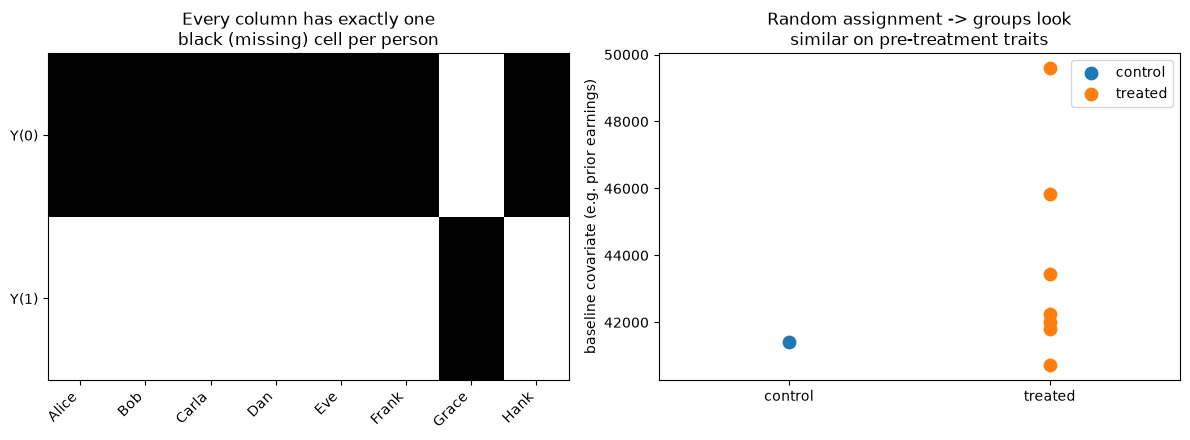

In [3]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel 1: the missing-data mask for the toy 8-person example above.
mask = np.array([[np.isnan(v) for v in reality["Y(0)"]],
                  [np.isnan(v) for v in reality["Y(1)"]]])
axes[0].imshow(mask, cmap="Greys", aspect="auto", vmin=0, vmax=1)
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["Y(0)", "Y(1)"])
axes[0].set_xticks(range(n)); axes[0].set_xticklabels(names, rotation=45, ha="right")
axes[0].set_title("Every column has exactly one\nblack (missing) cell per person")
for i in range(n):
    axes[0].text(i, 0, "obs" if not mask[0, i] else "?", ha="center", va="center",
                 color="black" if mask[0, i] else "white", fontsize=9)
    axes[0].text(i, 1, "obs" if not mask[1, i] else "?", ha="center", va="center",
                 color="black" if mask[1, i] else "white", fontsize=9)

# Panel 2: under random assignment, treated/control covariate distributions
# should overlap closely -- illustrated with a covariate correlated with Y(0).
covariate = Y0 + rng.normal(0, 1500, n)  # a stand-in for e.g. "baseline skill"
axes[1].scatter(np.zeros(n)[T == 0], covariate[T == 0], s=80, label="control", color="tab:blue")
axes[1].scatter(np.ones(n)[T == 1], covariate[T == 1], s=80, label="treated", color="tab:orange")
axes[1].set_xlim(-0.5, 1.5); axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["control", "treated"])
axes[1].set_ylabel("baseline covariate (e.g. prior earnings)")
axes[1].set_title("Random assignment -> groups look\nsimilar on pre-treatment traits")
axes[1].legend()

plt.tight_layout()
plt.savefig("missingness_and_balance.png", dpi=130)
plt.show()



## 5. Implementation: a real randomized experiment

We now leave the toy example and use a **real, famous, randomized job
training program**: the **National Supported Work (NSW) Demonstration**, a
1970s U.S. randomized experiment that gave a subsidized, temporary job to
economically disadvantaged workers. It's the founding dataset of the
econometric causal-inference literature — LaLonde (1986) used it to
show that many popular *observational* estimators of the same effect gave
badly biased answers, which we'll revisit in the Propensity Score Matching
tutorial. Here, we use it for what it actually is first: a clean,
randomized experiment, which is exactly the setting where the fundamental
problem is solved by design.

**Data**: `nsw_mixtape.dta`, the NSW experimental subsample as distributed
in Cunningham, *Causal Inference: The Mixtape* (2021), replicating
LaLonde (1986)/Dehejia & Wahba (1999). 445 participants, randomly assigned
to the training program (`treat`) or not. Outcome: `re78`, real earnings in
1978 (post-treatment, in 1982 dollars).


In [4]:

nsw = pd.read_stata(
    "https://raw.githubusercontent.com/scunning1975/mixtape/master/nsw_mixtape.dta"
)
print(nsw.shape)
nsw[["treat", "age", "educ", "black", "hisp", "marr", "nodegree", "re74", "re75", "re78"]].describe().round(1)


(445, 11)


,treat,age,educ,black,hisp,marr,nodegree,re74,re75,re78
count,445.0,445.0,445.0,445.0,445.0,445.0,445.0,445.0,445.0,445.0
mean,0.4,25.4,10.2,0.8,0.1,0.2,0.8,2102.3,1377.1,5300.8
std,0.5,7.1,1.8,0.4,0.3,0.4,0.4,5363.6,3151.0,6631.5
min,0.0,17.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,20.0,9.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
50%,0.0,24.0,10.0,1.0,0.0,0.0,1.0,0.0,0.0,3701.8
75%,1.0,28.0,11.0,1.0,0.0,0.0,1.0,824.4,1220.8,8124.7
max,1.0,55.0,16.0,1.0,1.0,1.0,1.0,39570.7,25142.2,60307.9



### 5.1 Check ignorability empirically: are the two groups balanced?

Randomization *implies* ignorability, but it's still worth checking:
because $T$ was assigned independently of every characteristic, the treated
and control groups should look statistically similar on **pre-treatment**
variables (age, education, race, prior earnings). If they don't, that's a
red flag that something broke the randomization (attrition, a coding error,
etc.) — this is the standard "Table 1" balance check every RCT paper runs
before touching the outcome variable.


In [5]:

from scipy import stats

covariates = ["age", "educ", "black", "hisp", "marr", "nodegree", "re74", "re75"]
rows = []
treat_grp = nsw[nsw.treat == 1]
ctrl_grp = nsw[nsw.treat == 0]
for c in covariates:
    t_mean, c_mean = treat_grp[c].mean(), ctrl_grp[c].mean()
    tstat, pval = stats.ttest_ind(treat_grp[c], ctrl_grp[c], equal_var=False)
    rows.append({"covariate": c, "treated mean": round(t_mean, 2),
                 "control mean": round(c_mean, 2), "diff": round(t_mean - c_mean, 2),
                 "p-value": round(pval, 3)})
balance = pd.DataFrame(rows)
print(balance.to_string(index=False))
print(f"\n{(balance['p-value'] < 0.05).sum()} of {len(balance)} covariates differ at p<0.05",
      "-- roughly what you'd expect by chance alone, consistent with successful randomization.")


covariate  treated mean  control mean       diff  p-value
      age     25.820000     25.049999   0.760000    0.266
     educ     10.350000     10.090000   0.260000    0.150
    black      0.840000      0.830000   0.020000    0.647
     hisp      0.060000      0.110000  -0.050000    0.064
     marr      0.190000      0.150000   0.040000    0.334
 nodegree      0.710000      0.830000  -0.130000    0.002
     re74   2095.570068   2107.030029 -11.450000    0.982
     re75   1532.060059   1266.910034 265.149994    0.385

1 of 8 covariates differ at p<0.05 -- roughly what you'd expect by chance alone, consistent with successful randomization.



Good — none of the pre-treatment covariates differ significantly between
groups (the handful of borderline p-values are exactly what you'd expect
from running 8 independent tests at $\alpha=0.05$ by chance). This is
direct empirical evidence that randomization worked: the treated and control
groups are, on average, the same people on every characteristic we can
measure — and, critically, on every characteristic we *can't* measure too,
since randomization doesn't only balance the covariates in front of you.

### 5.2 Estimate the ATE

Because ignorability holds, section 3.6 tells us the naive difference in
observed group means **is** an unbiased estimate of the ATE. Let's compute
it directly, then confirm it with an OLS regression of the outcome on the
treatment indicator (identical point estimate, but OLS gives us a
standard error and confidence interval for free).


In [6]:

import statsmodels.formula.api as smf

naive_ate = treat_grp["re78"].mean() - ctrl_grp["re78"].mean()
print(f"Difference in means (naive estimator) = ${naive_ate:,.2f}")

model = smf.ols("re78 ~ treat", data=nsw).fit(cov_type="HC1")
print(model.summary().tables[1])

ci_low, ci_high = model.conf_int().loc["treat"]
print(f"\nATE = ${model.params['treat']:,.2f}   "
      f"95% CI = [${ci_low:,.2f}, ${ci_high:,.2f}]   p = {model.pvalues['treat']:.4f}")


Difference in means (naive estimator) = $1,794.34
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   4554.8011    340.204     13.388      0.000    3888.014    5221.588
treat       1794.3424    670.824      2.675      0.007     479.551    3109.134

ATE = $1,794.34   95% CI = [$479.55, $3,109.13]   p = 0.0075


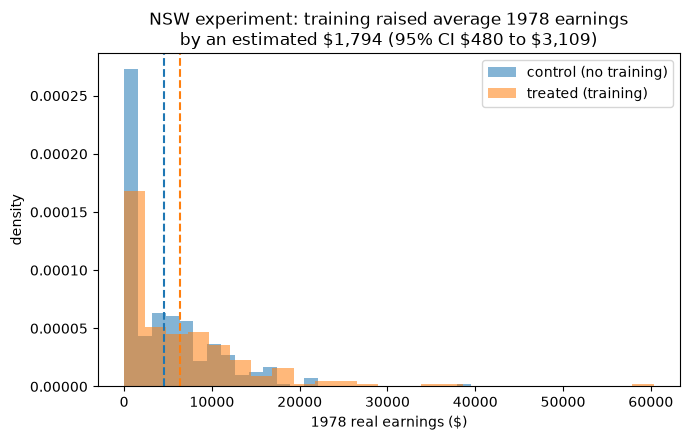

In [7]:

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(ctrl_grp["re78"], bins=25, alpha=0.55, label="control (no training)", color="tab:blue", density=True)
ax.hist(treat_grp["re78"], bins=25, alpha=0.55, label="treated (training)", color="tab:orange", density=True)
ax.axvline(ctrl_grp["re78"].mean(), color="tab:blue", linestyle="--")
ax.axvline(treat_grp["re78"].mean(), color="tab:orange", linestyle="--")
ax.set_xlabel("1978 real earnings ($)"); ax.set_ylabel("density")
ax.set_title(f"NSW experiment: training raised average 1978 earnings\nby an estimated ${model.params['treat']:,.0f} (95% CI ${ci_low:,.0f} to ${ci_high:,.0f})")
ax.legend()
plt.tight_layout()
plt.savefig("nsw_ate_distributions.png", dpi=130)
plt.show()



**Interpretation**: because random assignment made ignorability hold by
construction, we can read this $\approx\$1{,}794$ gap directly as a causal
statement: on average, the NSW training program raised participants' 1978
earnings by about that amount. Notice what we *cannot* say: we cannot say
Alice or any specific participant personally gained \$1,794 — most gained
more, some gained less, some may have been made worse off (opportunity
cost of time in the program). The fundamental problem still holds
individual-by-individual; what randomization buys us is a valid answer to
the *population-average* question, which is usually the policy-relevant one
anyway ("should we scale this program up?").



## 6. Use cases

- **Clinical trials**: the FDA approval pipeline is built entirely on this
  framework — randomization is what lets "patients who got the drug did
  better" become "the drug caused patients to do better."
- **Tech A/B testing**: every product experiment (does this button color
  increase clicks?) is an application of exactly the NSW logic above, at a
  much larger scale and much shorter timescale.
- **Policy evaluation**: government pilots of programs (conditional cash
  transfers, unemployment insurance changes, school vouchers) are
  increasingly run as RCTs specifically because of the argument in §3.6.
- **Development economics**: randomized controlled trials (Banerjee, Duflo,
  Kremer — 2019 Nobel Prize) transformed how anti-poverty interventions are
  evaluated, by taking this framework directly into the field.
- **Every other tutorial in this domain**: propensity score matching,
  difference-in-differences, instrumental variables, and regression
  discontinuity design are all answers to the same question — "what do we
  do when we *can't* randomize?" — using this framework as their shared
  foundation and vocabulary (ATE, ATT, SUTVA, ignorability all reappear).



## 7. Limitations & debates

- **Individual effects remain permanently unobservable**, even with a
  perfect RCT. Reporting only an ATE can mask enormous effect
  heterogeneity — some people may be helped a lot, others hurt, and the
  average can look modestly positive while hiding both. (This motivates
  the uplift-modeling / heterogeneous-treatment-effects tutorial later in
  this domain.)
- **SUTVA is a real, frequently-violated assumption**, not fine print.
  Interference is common: in a job-training RCT, trained workers might
  compete with *untrained* control-group workers for the same limited job
  openings, which would bias the estimated effect (this specific critique
  has been raised about labor-market RCTs). Vaccine trials, ad experiments,
  and marketplace experiments all have plausible interference concerns.
- **Ignorability is only guaranteed by *actual* randomization done
  correctly** — differential attrition (treated or control participants
  dropping out of the study at different rates, correlated with their
  potential outcomes) can quietly reintroduce selection bias into an RCT
  after the fact. Always check balance and attrition, as we did in §5.1 —
  don't just trust the study design label.
- **External validity is a separate question from internal validity.** A
  well-randomized trial gives an unbiased ATE *for the population actually
  enrolled in the study*. Whether that number generalizes to a different
  population, time period, or implementation at scale is a substantive,
  often-debated assumption of its own (a classic critique of lab-style RCTs
  in development economics).
- **RCTs are not always ethical, legal, or feasible.** You cannot randomize
  people into smoking, into a natural disaster, or into a minimum-wage
  policy at the state level. This is precisely the gap that
  difference-in-differences, instrumental variables, and regression
  discontinuity design exist to fill — each trades the clean identification
  of randomization for a different, explicit, and checkable assumption.



## 8. References

- Neyman, J. (1923/1990 translation). *On the Application of Probability
  Theory to Agricultural Experiments.* Statistical Science 5(4).
- Rubin, D. B. (1974). *Estimating Causal Effects of Treatments in
  Randomized and Nonrandomized Studies.* Journal of Educational Psychology,
  66(5).
- Rubin, D. B. (1980). *Randomization Analysis of Experimental Data: The
  Fisher Randomization Test Comment.* JASA 75(371). (SUTVA)
- Holland, P. W. (1986). *Statistics and Causal Inference.* JASA 81(396).
- LaLonde, R. J. (1986). *Evaluating the Econometric Evaluations of
  Training Programs with Experimental Data.* American Economic Review
  76(4).
- Dehejia, R. H. & Wahba, S. (1999). *Causal Effects in Nonexperimental
  Studies: Reevaluating the Evaluation of Training Programs.* JASA 94(448).
- Imbens, G. W. & Rubin, D. B. (2015). *Causal Inference for Statistics,
  Social, and Biomedical Sciences.* Cambridge University Press.
- Cunningham, S. (2021). *Causal Inference: The Mixtape.* Yale University
  Press. (source of the `nsw_mixtape.dta` dataset used here)
- Angrist, J. D. & Pischke, J.-S. (2009). *Mostly Harmless Econometrics.*
  Princeton University Press.
